# When a reassuring average hides a risk: treatment delay and ED mortality

**Question.** Among emergency-department visits with severity levels 1–3, how would mortality risk differ if treatment began at least 160 minutes after triage rather than sooner?

## TL;DR

The full dataset appears to show *lower* mortality with longer delays. That is a misleading average: severely ill patients are treated sooner and also die more often. Once the analysis targets low-severity visits, the crude direction reverses. A cross-fitted, propensity-score-based doubly robust estimator produces an adjusted risk difference of **+0.66 percentage points** (95% CI **−0.89 to +2.22**). The interval includes no effect, so this is a transparent causal-analysis case study—not evidence for a clinical rule.

This notebook is the narrative companion to the tested pipeline in [`analysis.py`](../analysis.py). It intentionally excludes row-level data and replaces the original 12 MB of embedded screenshots with reproducible code and lightweight outputs.

## 1. Why causal inference is needed

An ideal randomized controlled trial (RCT) would assign otherwise comparable visits to different treatment-start times. Randomization would make treatment timing independent of baseline prognosis, on average. Deliberately assigning harmful delays, however, may be unethical or operationally impossible.

Observational causal inference can **emulate parts of that comparison** by defining a target intervention and adjusting for measured pre-treatment differences. It is not a substitute for randomization: its validity still requires consistency, positivity, correct time ordering, and no important unmeasured confounding.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "analysis.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from analysis import define_cohort, estimate_effect, load_analysis_data

DATA_PATH = Path(
    os.environ.get("MORTALITY_XLSX", REPO_ROOT / "data" / "raw" / "mortality.xlsx")
).resolve()
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Place mortality.xlsx in data/raw/ or set the MORTALITY_XLSX environment variable."
    )

THRESHOLD = 160
data, quality = load_analysis_data(DATA_PATH)
cohort = define_cohort(data, max_severity=3)

pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## 2. Data and target population

The workbook contains one model row per visit. Patient identifiers are recovered from the visit table so repeated visits can remain together during cross-fitting and uncertainty can be clustered by patient. The primary cohort is prespecified as severity levels 1–3; this makes the code match the project title and avoids presenting a post-hoc subgroup as the main analysis.

In [2]:
overview = pd.DataFrame(
    {
        "Full dataset": [len(data), data["Patient_ID"].nunique(), int(data["Mortality_Flag"].sum())],
        "Low-severity cohort": [len(cohort), cohort["Patient_ID"].nunique(), int(cohort["Mortality_Flag"].sum())],
    },
    index=["Visits", "Unique patients", "Deaths"],
)
display(overview)
print(f"Observation period: {quality['arrival_date_min'][:10]} to {quality['arrival_date_max'][:10]}")
print(f"Required-field nulls in the model table: {quality['required_field_nulls']}")

,Full dataset,Low-severity cohort
Visits,9994,5216
Unique patients,9738,5139
Deaths,332,102


Observation period: 2024-01-01 to 2025-12-31
Required-field nulls in the model table: 0


## 3. The Simpson's paradox story

Three descriptive views explain the reversal:

1. **The aggregate comparison looks protective.** Across all visits, mortality is lower in the high-delay group.
2. **Severity strongly predicts mortality.** Higher severity levels have substantially higher observed mortality.
3. **Severity also predicts treatment timing.** High-severity visits are concentrated in the shorter-delay group.

Pooling these different severity profiles mixes prognosis with treatment timing. Restricting the target population to levels 1–3 reverses the crude comparison, which is the warning sign that motivates—not proves—the causal analysis.

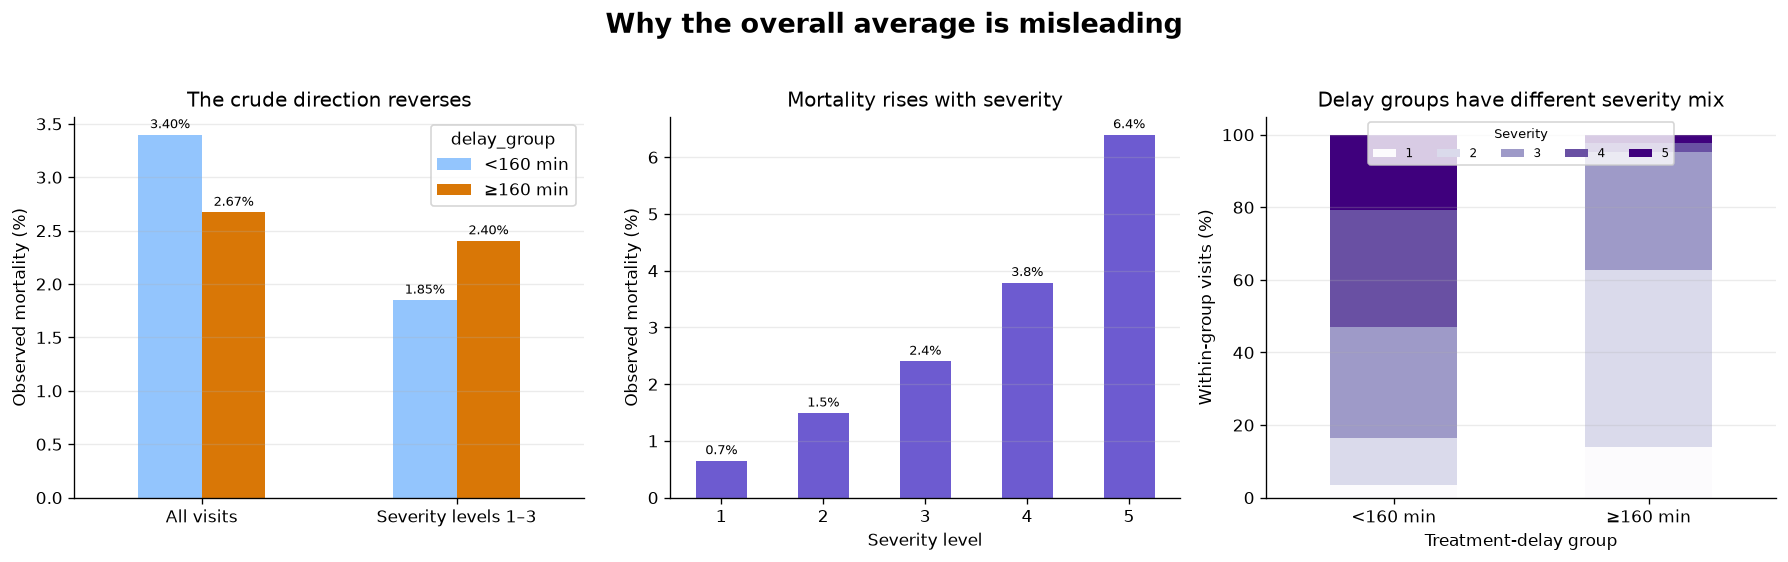

In [3]:
def delay_label(frame):
    return np.where(frame["Treatment_Delay_Minutes"].ge(THRESHOLD), "≥160 min", "<160 min")

all_plot = data.assign(delay_group=delay_label(data), population="All visits")
low_plot = cohort.assign(delay_group=delay_label(cohort), population="Severity levels 1–3")
combined = pd.concat([all_plot, low_plot], ignore_index=True)

crude = (
    combined.groupby(["population", "delay_group"], observed=True)["Mortality_Flag"]
    .mean().mul(100).unstack()
    .reindex(["All visits", "Severity levels 1–3"])[["<160 min", "≥160 min"]]
)
severity_risk = data.groupby("Severity_Level")["Mortality_Flag"].mean().mul(100)
mix = (
    all_plot.groupby(["delay_group", "Severity_Level"], observed=True).size().unstack(fill_value=0)
    .reindex(["<160 min", "≥160 min"])
)
mix = mix.div(mix.sum(axis=1), axis=0).mul(100)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
colors = ["#93C5FD", "#D97706"]
crude.plot.bar(ax=axes[0], color=colors, rot=0)
axes[0].set(title="The crude direction reverses", xlabel="", ylabel="Observed mortality (%)")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.2f%%", padding=2, fontsize=8)

severity_risk.plot.bar(ax=axes[1], color="#6D5BD0", rot=0)
axes[1].set(title="Mortality rises with severity", xlabel="Severity level", ylabel="Observed mortality (%)")
axes[1].bar_label(axes[1].containers[0], fmt="%.1f%%", padding=2, fontsize=8)

mix.plot.bar(ax=axes[2], stacked=True, colormap="Purples", rot=0)
axes[2].set(title="Delay groups have different severity mix", xlabel="Treatment-delay group", ylabel="Within-group visits (%)")
axes[2].legend(title="Severity", ncol=5, fontsize=7, title_fontsize=8, loc="upper center")

for axis in axes:
    axis.grid(axis="y", alpha=0.25)
fig.suptitle("Why the overall average is misleading", fontsize=16, fontweight="bold", y=1.03)
fig.tight_layout()
plt.show()

## 4. From observed groups to an adjusted contrast

The exposure is `Treatment_Delay_Minutes ≥ 160`; the outcome is in-visit mortality. The estimand is the **average treatment effect (ATE) risk difference** in the eligible low-severity cohort.

The propensity score estimates each visit's probability of high delay from measured pre-treatment characteristics. Inverse-probability weights create a pseudo-population in which those characteristics are more comparable across delay groups. Balance is assessed with standardized mean differences (SMDs), rather than comparing a single weighted bar.

The final estimator is augmented inverse probability weighting (AIPW):

$$
\hat\psi_a = \frac{1}{n}\sum_i\left[\hat m_a(X_i) +
\frac{\mathbb{1}(A_i=a)}{\hat P(A_i=a\mid X_i)}\{Y_i-\hat m_a(X_i)\}\right].
$$

It is called **doubly robust** because it can be consistent when either the propensity model or the outcome model is correctly specified—provided the other causal assumptions hold. Both nuisance models are cross-fitted by patient here, which reduces overfitting bias and prevents a patient's repeated visits from crossing folds.

In [4]:
estimate, balance = estimate_effect(cohort, threshold_minutes=THRESHOLD, folds=5, seed=42)

results = pd.DataFrame(
    {"Estimate": [
        estimate.crude_risk_unexposed, estimate.crude_risk_exposed,
        estimate.crude_risk_difference, estimate.adjusted_risk_unexposed,
        estimate.adjusted_risk_exposed, estimate.adjusted_risk_difference,
        estimate.ci_low, estimate.ci_high,
    ]},
    index=[
        "Crude risk, <160 min", "Crude risk, ≥160 min", "Crude risk difference",
        "AIPW risk, <160 min", "AIPW risk, ≥160 min", "AIPW risk difference",
        "95% CI lower bound", "95% CI upper bound",
    ],
).mul(100).rename(columns={"Estimate": "Percentage points / percent"})
display(results.round(2))

,Percentage points / percent
"Crude risk, <160 min",1.850
"Crude risk, ≥160 min",2.400
Crude risk difference,0.560
"AIPW risk, <160 min",1.760
"AIPW risk, ≥160 min",2.420
AIPW risk difference,0.660
95% CI lower bound,-0.890
95% CI upper bound,2.220


,Value
Maximum |SMD| before weighting,0.921
Maximum |SMD| after weighting,0.100
Features with |SMD| ≥ 0.10 before,8.000
Features with |SMD| ≥ 0.10 after,1.000
Raw propensity minimum,0.011
Raw propensity maximum,1.000
Propensities clipped,14.000
99th percentile IPTW,14.529
Maximum IPTW,100.000
"Effective sample size, high delay",496.768


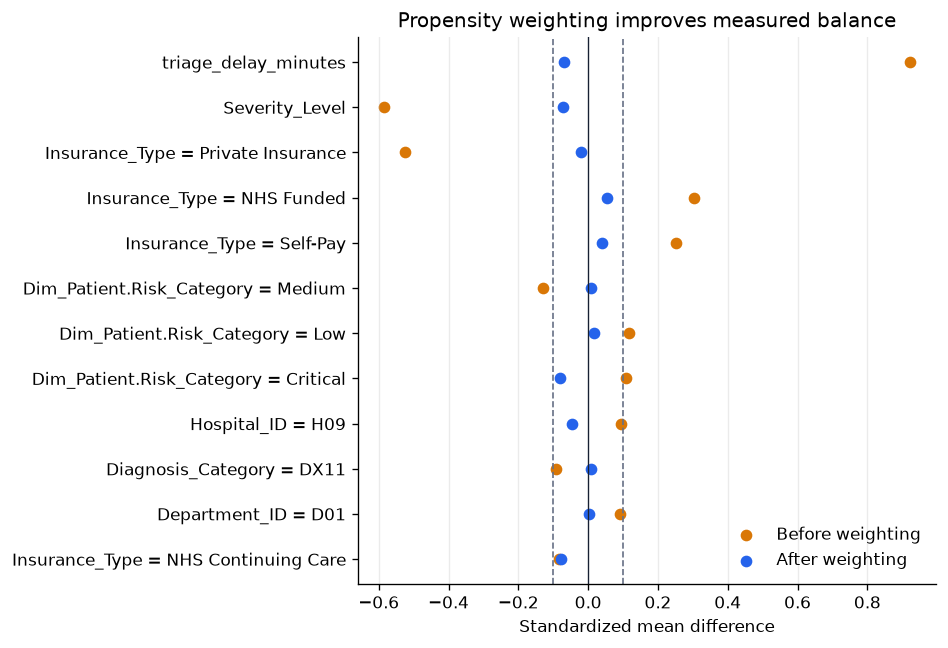

In [5]:
diagnostics = pd.Series(
    {
        "Maximum |SMD| before weighting": estimate.max_abs_smd_before,
        "Maximum |SMD| after weighting": estimate.max_abs_smd_after,
        "Features with |SMD| ≥ 0.10 before": estimate.imbalanced_features_before,
        "Features with |SMD| ≥ 0.10 after": estimate.imbalanced_features_after,
        "Raw propensity minimum": estimate.propensity_min_raw,
        "Raw propensity maximum": estimate.propensity_max_raw,
        "Propensities clipped": estimate.propensity_clipped_count,
        "99th percentile IPTW": estimate.weight_p99,
        "Maximum IPTW": estimate.max_weight,
        "Effective sample size, high delay": estimate.ess_exposed,
        "Effective sample size, lower delay": estimate.ess_unexposed,
    }, name="Value"
).to_frame()
display(diagnostics.round(3))

top_balance = balance.nlargest(12, "abs_smd_before").sort_values("abs_smd_before")
fig, ax = plt.subplots(figsize=(8, 5.5))
positions = np.arange(len(top_balance))
ax.scatter(top_balance["smd_before"], positions, label="Before weighting", color="#D97706")
ax.scatter(top_balance["smd_after"], positions, label="After weighting", color="#2563EB")
ax.axvline(-0.10, color="#667085", linestyle="--", linewidth=1)
ax.axvline(0.10, color="#667085", linestyle="--", linewidth=1)
ax.axvline(0, color="#172033", linewidth=0.8)
ax.set(yticks=positions, yticklabels=top_balance["feature"], xlabel="Standardized mean difference", title="Propensity weighting improves measured balance")
ax.legend(frameon=False)
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
plt.show()

## 5. Interpretation

The adjusted point estimate suggests **0.66 additional deaths per 100 visits** under high delay, on the risk-difference scale. The 95% confidence interval ranges from **0.89 fewer to 2.22 additional deaths per 100 visits**, so the data are compatible with no difference as well as clinically meaningful harm.

The propensity diagnostics also temper the conclusion: measured balance improves substantially, but some observations have near-extreme propensities and large weights. Doubly robust does not mean assumption-free, and it does not protect against unmeasured factors such as staffing, crowding, calendar time, or clinician judgment.

## Takeaways

- The pooled average is misleading because severity affects both treatment timing and mortality—a classic Simpson's paradox pattern.
- Propensity scores address measured differences in treatment assignment; the outcome model adds a second adjustment route.
- Cross-fitted AIPW is a stronger implementation of the intended doubly robust method than the original in-sample, class-weighted notebook estimate.
- This workflow can frame an RCT-like intervention contrast when randomization is infeasible, but its conclusion remains conditional on observational causal assumptions.
- The result supports further study and better operational measurement, not a claim that 160 minutes is a proven clinical cutoff.

See the [methodology](../reports/methodology.md), [validation report](../reports/validation_report.md), and [full figure set](../figures/) for the audit trail.